In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import itertools

def runge_kutta(time_steps, y0, system, params):
    ys = [y0]
    for t in range(len(time_steps)-1):
        dt = time_steps[t+1]-time_steps[t]
        t0 = time_steps[t]
        t1 = time_steps[t+1]
        k1 = system(t0, y0, params)
        k2 = system(t0 + dt/2, y0 + dt / 2 * k1, params)
        k3 = system(t0 + dt/2, y0 + dt / 2 * k2, params)
        k4 = system(t1, y0 + dt * k3, params)
        y0  = y0 + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        ys.append(y0)
    return np.array(ys)

def lorentz_ode(t, xyz, params):
    x, y, z = xyz
    σ = params['σ']
    ρ = params['ρ']
    β = params['β']

    dx = σ * (y - x)
    dy = x * (ρ - z) - y
    dz = x * y - β * z

    return np.array([dx, dy, dz])

time_steps = np.arange(0, 2000, 0.1)
params = {'σ' : 10., 'ρ' : 28., 'β' : 8/3}
xyz0 = np.array([1., 1., 1.])
lorenz_solution = runge_kutta(time_steps, xyz0, lorentz_ode, params)
x, y, z = lorenz_solution[2000:].T
x = (x - min(x)) / (max(x) - min(x))

In [2]:
def Probability(Data, M = 6):
    z = np.zeros((len(Data) + 1 - M, M))
    for i in range(len(Data) + 1 - M):
        for j in range(M):
            z[i][j] = Data[i + j]
            
    e = np.zeros((len(z), M))
    for i in range(len(z)):
        e[i] = np.argsort(z[i])
        
    fact = math.factorial(M)
    p0 = np.zeros(4)
    p1 = np.zeros((fact, M))
    p2 = np.zeros(fact)
    count = 0
    for i in range(len(e)):
        for j in range(fact):
            if (np.array_equal(p1[j], p0)):
                p1[j] = e[i]
                p2[j] = 1
                count = j + 1
                break
            elif (np.array_equal(p1[j], e[i])):
                p2[j] += 1
                break
            
    p3 = np.zeros(count)
    sum = np.sum(p2)
    for i in range(count):
        p3[i] = p2[i] / sum
        
    return p3

def Probability_U(P):
    return np.full(shape=len(P), fill_value=1/len(P))

def Probability_Const(P):
    p = np.zeros(len(P))
    p[0] = 1
    return p

def Entropy(P):
    s = 0
    for i in range(len(P)):
        if (P[i] != 0):
            s = s - P[i] * np.log2(P[i])
    return s

def J(P1, P2):
    P3 = np.add(P1, P2) / 2
    return Entropy(P3) - 0.5 * (Entropy(P1) + Entropy(P2))

In [28]:
m = 5
tau = 1
min_neighbors = 10
max_time = 5
min_distance = 0
max_distance = 0.01
exclude_time = 0

def Reconstruction(Data):
    M = len(Data) -(m - 1) * tau
    Y = np.zeros((M, m))
    
    for i in range(M):
        for j in range(m):
            Y[i][j] = Data[i + j * tau]
    
    return Y

def Search_Neighbors(Y):
    N = []

    for i in range(len(Y)):
        N.append([])
        for j in range(i):
            if (i - j > exclude_time):
                lin_norm = np.linalg.norm(Y[i] - Y[j])
                if (lin_norm >= min_distance and lin_norm <= max_distance):
                    N[i].append(j)
                    N[j].append(i)

    for i in range(len(N)):
        if (len(N[i]) < min_neighbors):
            N[i] = []
    
    return N

def Time_Differences(Y, N):
    d = []

    for i in range(len(Y)):
        d.append([])
        for j in range(len(N[i])):
            d[i].append([])
            for k in range(max_time):
                if (max(i, j) + k < len(Y)):
                    d[i][j].append(np.linalg.norm(Y[i + k] - Y[j + k]))
    
    return d

def Averaging(Y, N, d):
    M0 = 0
    S = []

    for i in range(len(Y)):
        if (len(N[i]) >= min_neighbors):
            M0 += 1

    for k in range(max_time):
        S1 = 0
        for i in range(len(N)):
            S2 = 0
            if (len(N[i]) > 0):
                for j in range(len(N[i])):
                    if (d[i][j][k] != 0):
                        S2 = S2 + np.log(d[i][j][k])
                S2 = S2 / len(N[i])
            S1 = S1 + S2
        S.append(S1 / M0)

    return S

In [4]:
Data = x.copy()
Y = Reconstruction(Data)
print(Y, len(Y))

[[0.5233603  0.54187903 0.59445774 0.72342906 0.92283056]
 [0.54187903 0.59445774 0.72342906 0.92283056 0.83563623]
 [0.59445774 0.72342906 0.92283056 0.83563623 0.60507047]
 ...
 [0.29302634 0.16140082 0.14936898 0.28809963 0.39578869]
 [0.16140082 0.14936898 0.28809963 0.39578869 0.41928787]
 [0.14936898 0.28809963 0.39578869 0.41928787 0.39047762]] 17996


In [15]:
N = Search_Neighbors(Y)

In [24]:
d = Time_Differences(Y, N)

In [29]:
S = Averaging(Y, N, d)

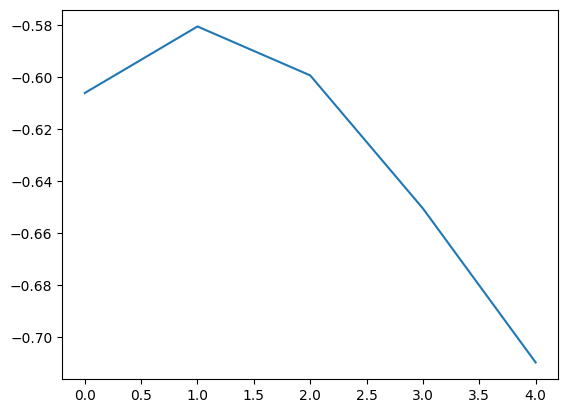

In [31]:
plt.plot(S)
plt.show() 

In [3]:
from scipy.io import arff
import pandas as pd

raw_data, meta = arff.loadarff('AbnormalHeartbeat_TEST.arff')
df = pd.DataFrame(raw_data)
feature_columns = [col for col in df.columns if col != 'target']
X = df[feature_columns].values.astype(np.float32)
Y = df['target'].values

ModuleNotFoundError: No module named 'pandas'

In [55]:
Normal_Entropy = []
Normal_Complexity = []
Abnormal_Entropy = []
Abnormal_Complexity = []

for i in range(len(X)):
    data = X[i].copy()
    prob = Probability(data)
    prob_u = Probability_U(prob)
    prob_const = Probability_Const(prob)
    entropy = Entropy(prob) / Entropy(prob_u)
    complexity = J(prob, prob_u) / J(prob_u, prob_const)
    
    if (Y[i] == b'Normal'):
        Normal_Entropy.append(entropy)
        Normal_Complexity.append(complexity)
    else:
        Abnormal_Entropy.append(entropy)
        Abnormal_Complexity.append(complexity)


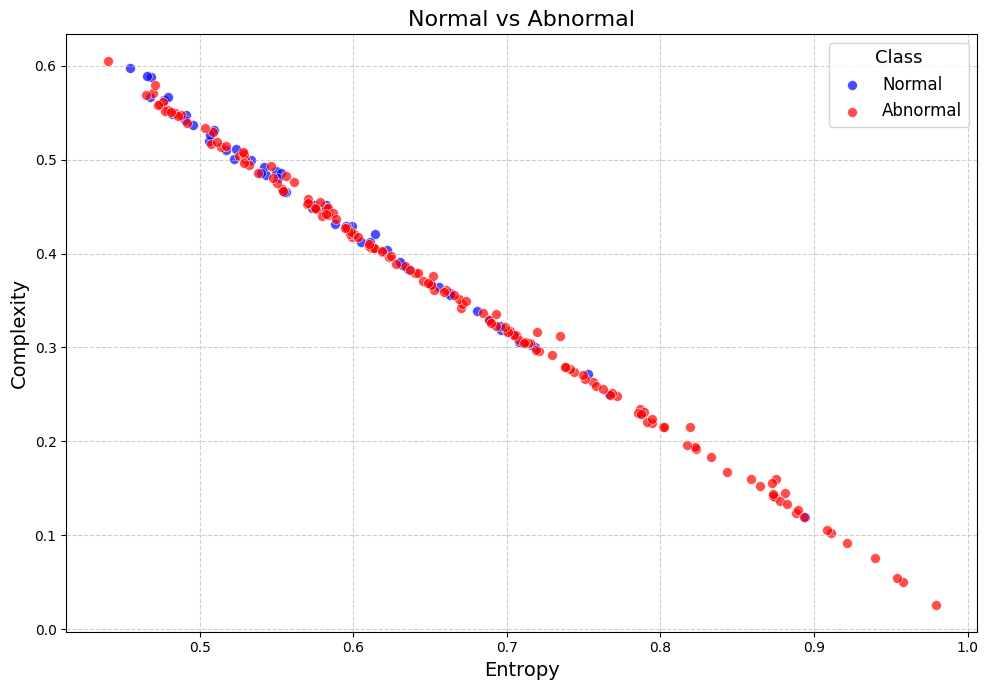

In [68]:
plt.figure(figsize=(10, 7))
plt.scatter(Normal_Entropy, Normal_Complexity, c='blue', label='Normal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c='red', label='Abnormal', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)

plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal vs Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, title="Class", title_fontsize=13)


plt.tight_layout()
plt.show()

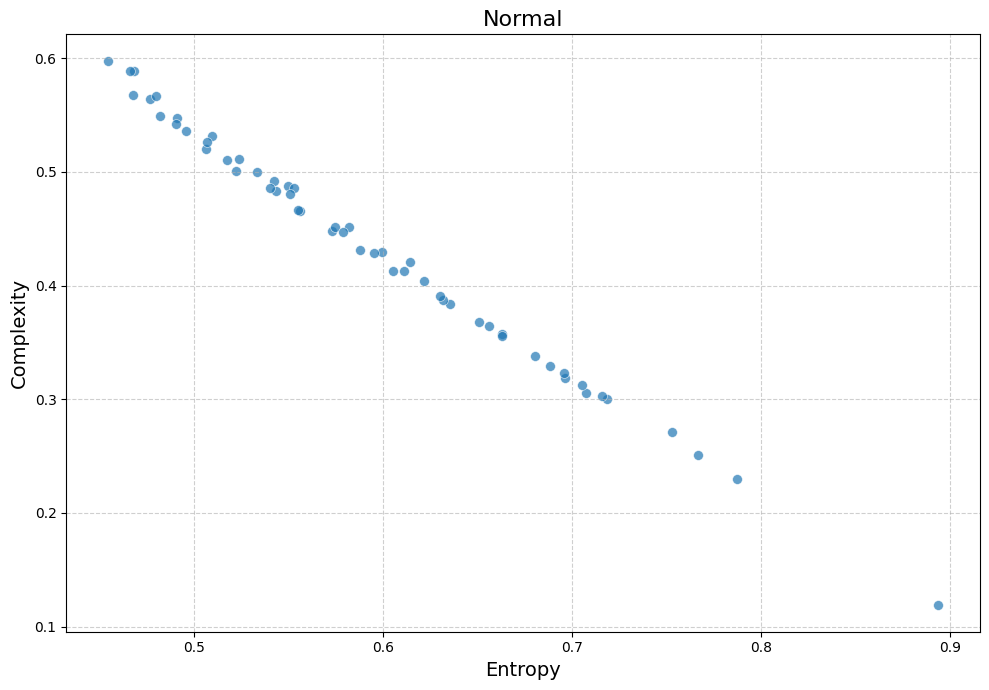

In [56]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(Normal_Entropy, Normal_Complexity, alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Normal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

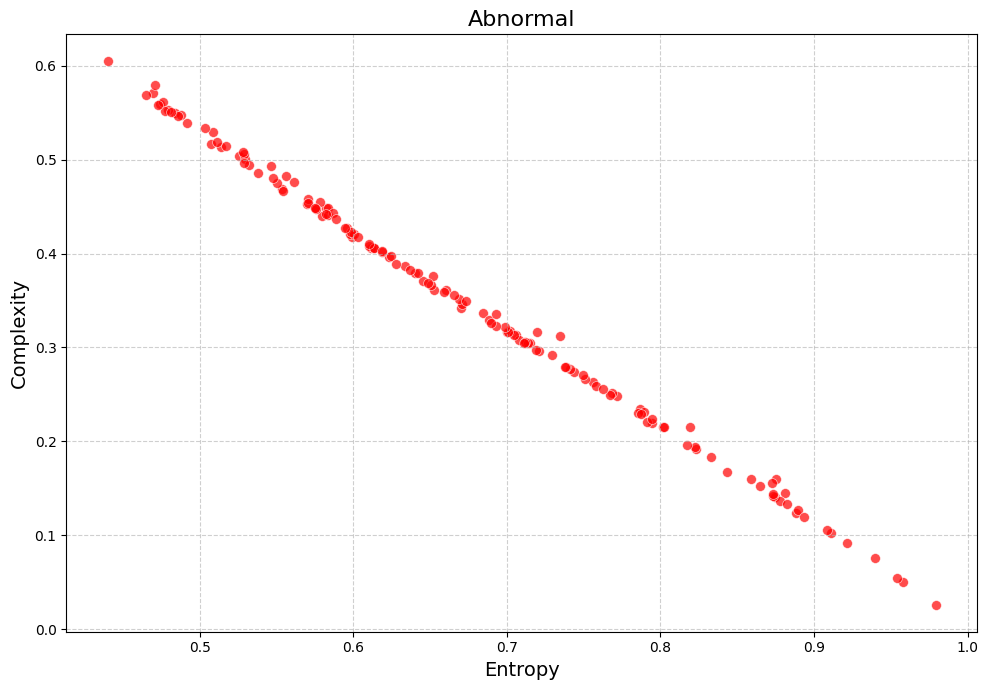

In [70]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(Abnormal_Entropy, Abnormal_Complexity, c = 'red', alpha=0.7, s=50, edgecolor='w', linewidth=0.5)
plt.xlabel('Entropy', fontsize=14)
plt.ylabel('Complexity', fontsize=14)
plt.title('Abnormal', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()